In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import string
import re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
from nltk.probability import FreqDist
import pymorphy3

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

In [4]:
with open('2013.txt', 'r') as file:
    data = file.read()

In [9]:
stop_words = stopwords.words('russian')
morph = pymorphy3.MorphAnalyzer()

In [11]:
def tokenize_text(raw_text: str):
    """Функция для токенизации текста
    :param raw_text: исходная текстовая строка
    """
    # Разбиение на сслова при помощи пробела
    words = raw_text.split()
    # Подготовка регулярного выражения для фильтрации символов
    re_punc = re.compile('[%s]' % re.escape(string.punctuation))
    # Удаление знаков препинания
    stripped = [re_punc.sub('', w) for w in words]
    # Приведение всех слов к нижнему регистру
    words_lower = [w.lower() for w in stripped]
    # Удаление оставшихся токенов, которые не являются буквами
    words_alpha = [word for word in words_lower if word.isalpha()]
    # Удаление стоп-слов    
    words_stop = [w for w in words_alpha if not w in stop_words]
    # Лемматизация    
    tokens = [morph.parse(token)[0].normal_form for token in words_stop]
    # Удалим короткие токены
    tokens = [word for word in tokens if len(word) > 2]
      
    return tokens

In [13]:
tokenized = tokenize_text(data)

In [15]:
all_words = FreqDist(tokenized)

In [17]:
print("Наиболлее популярные слова: ", all_words.most_common(100))
print("\nОбщее количество уникальных слов: ", len(all_words.keys()))

Наиболлее популярные слова:  [('развитие', 60), ('брикс', 49), ('страна', 47), ('встреча', 39), ('международный', 37), ('наш', 26), ('оон', 26), ('цель', 25), ('сотрудничество', 24), ('также', 23), ('год', 22), ('африка', 22), ('который', 21), ('вопрос', 21), ('банк', 19), ('безопасность', 18), ('министр', 18), ('мир', 17), ('экономика', 16), ('устойчивый', 16), ('поддерживать', 16), ('сторона', 15), ('подтверждать', 14), ('область', 14), ('создание', 14), ('усилие', 14), ('призывать', 14), ('центральный', 13), ('глобальный', 13), ('новый', 13), ('рост', 13), ('инфраструктура', 13), ('организация', 12), ('развивающийся', 12), ('приветствовать', 12), ('саммит', 11), ('роль', 11), ('африканский', 11), ('конференция', 11), ('право', 10), ('соответствующий', 10), ('процесс', 10), ('финансовый', 10), ('необходимость', 10), ('финансы', 10), ('система', 9), ('форум', 9), ('поддержка', 9), ('действие', 9), ('мера', 9), ('многосторонний', 9), ('принцип', 9), ('гуманитарный', 9), ('провести', 8)

C:\Temp\ipykernel_7612\1563493910.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


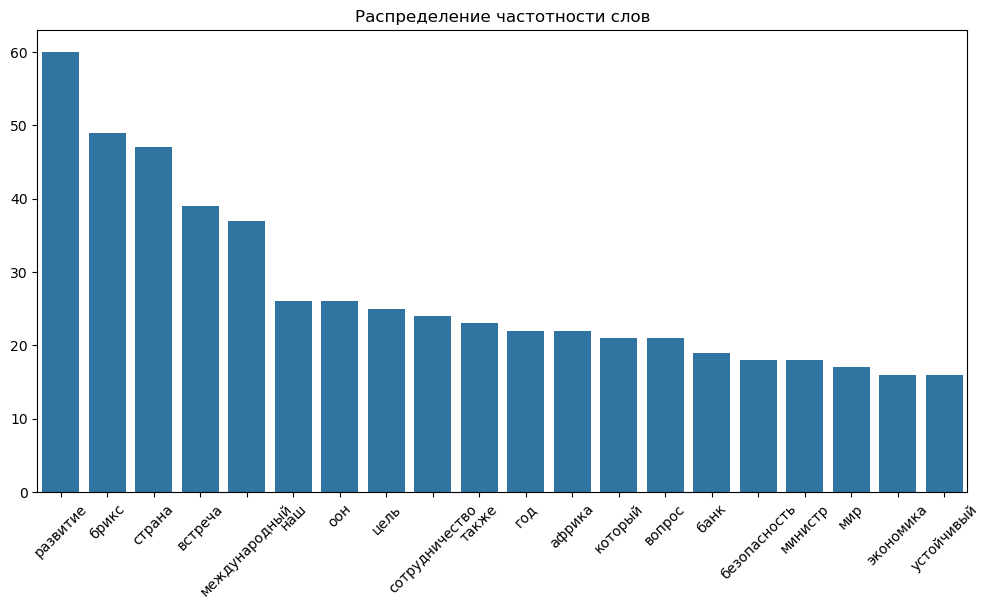

In [19]:
count, words = [], []
for w in all_words.most_common(20):
    words.append(w[0])
    count.append(w[1])
fig,ax = plt.subplots(figsize = (12,6))
ax = sns.barplot(x=words,y=count)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title ('Распределение частотности слов')
plt.show()

In [21]:
stop_words_ex = ['год','наш', 'который', 'также']
def stop_words_extra(text):
    return [w for w in text if not w in stop_words_ex]

In [23]:
tokens = stop_words_extra(tokenized)

C:\Temp\ipykernel_7612\3051857113.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


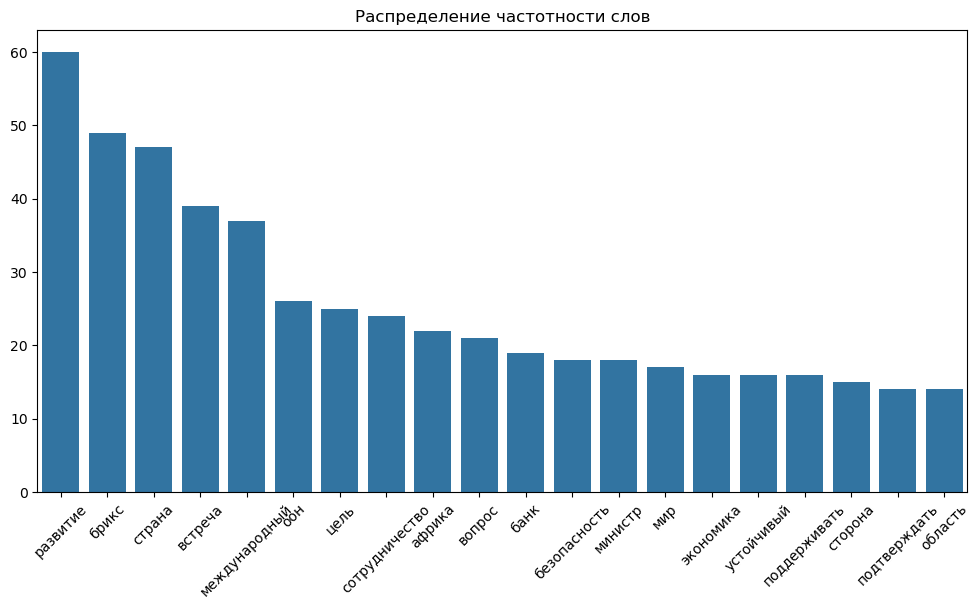

In [25]:
all_words = FreqDist(tokens)
count, words = [], []
for w in all_words.most_common(20):
    words.append(w[0])
    count.append(w[1])
fig,ax = plt.subplots(figsize = (12,6))
ax = sns.barplot(x=words,y=count)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title ('Распределение частотности слов')
plt.show()

In [27]:
textt = ','.join(w for w in tokens)

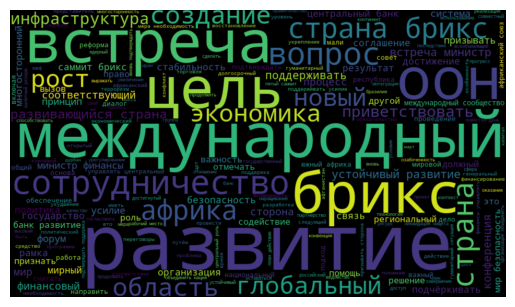

In [29]:
wordcloud = WordCloud(width=950,height=550).generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [31]:
# Приводим текст в векторное представление
tfidf_vect = TfidfVectorizer(max_df=1.0, min_df=2, stop_words=None)
doc_term_matrix = tfidf_vect.fit_transform(tokens)

### Латентное размещение Дерихле

In [34]:
LDA = LatentDirichletAllocation(n_components=2, random_state=42)
LDA.fit(doc_term_matrix)

LatentDirichletAllocation(n_components=2, random_state=42)

In [35]:
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['поддерживать', 'министр', 'банк', 'африка', 'сотрудничество', 'цель', 'оон', 'страна', 'брикс', 'развитие']


Top 10 words for topic #1:
['инфраструктура', 'призывать', 'область', 'создание', 'сторона', 'мир', 'безопасность', 'вопрос', 'международный', 'встреча']




In [38]:
LDA = LatentDirichletAllocation(n_components=3, random_state=42)
LDA.fit(doc_term_matrix)
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['саммит', 'организация', 'центральный', 'новый', 'поддерживать', 'устойчивый', 'министр', 'сотрудничество', 'брикс', 'развитие']


Top 10 words for topic #1:
['необходимость', 'роль', 'развивающийся', 'инфраструктура', 'рост', 'область', 'сторона', 'вопрос', 'международный', 'встреча']


Top 10 words for topic #2:
['призывать', 'создание', 'экономика', 'мир', 'безопасность', 'банк', 'африка', 'цель', 'оон', 'страна']




### Неотрицательная матричная факторизация

In [41]:
nmf = NMF(n_components=2, random_state=42)
nmf.fit(doc_term_matrix )
for i,topic in enumerate(nmf.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['цель', 'безопасность', 'вопрос', 'министр', 'банк', 'африка', 'сотрудничество', 'оон', 'встреча', 'развитие']


Top 10 words for topic #1:
['банк', 'вопрос', 'африка', 'сотрудничество', 'цель', 'оон', 'международный', 'встреча', 'страна', 'брикс']




In [43]:
nmf = NMF(n_components=3, random_state=42)
nmf.fit(doc_term_matrix )
for i,topic in enumerate(nmf.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['мир', 'экономика', 'организация', 'устойчивый', 'безопасность', 'вопрос', 'сотрудничество', 'оон', 'встреча', 'развитие']


Top 10 words for topic #1:
['африка', 'вопрос', 'экономика', 'поддерживать', 'министр', 'международный', 'сотрудничество', 'оон', 'встреча', 'брикс']


Top 10 words for topic #2:
['поддерживать', 'мир', 'безопасность', 'банк', 'африка', 'цель', 'оон', 'международный', 'встреча', 'страна']




Вывод: Анализируя декларацию 2013 г., была сформулирована гипотеза, что в связи с тем, что саммит проходил в ЮАР, африканской проблематике будет посвящена отдельная тема. Так по большому счету и произошло, хотя нельзя сказать, что африканская повестка была доминирующей. На встрече по-прежнему доминировали обсуждения общих проблем международного сотрудничества и глобального развития.